In [1]:
#Data Analytics II - Logistic Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('/home/student/Downloads/Social_Network_Ads1.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


array([[<Axes: title={'center': 'User ID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Purchased'}>]], dtype=object)

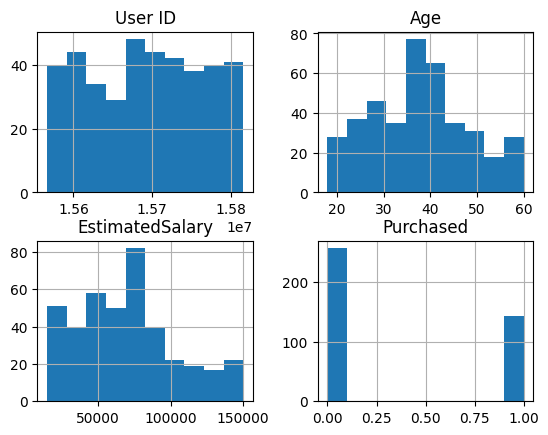

In [4]:
df.hist()

In [5]:
df.isnull().sum()


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.dropna()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


<Axes: >

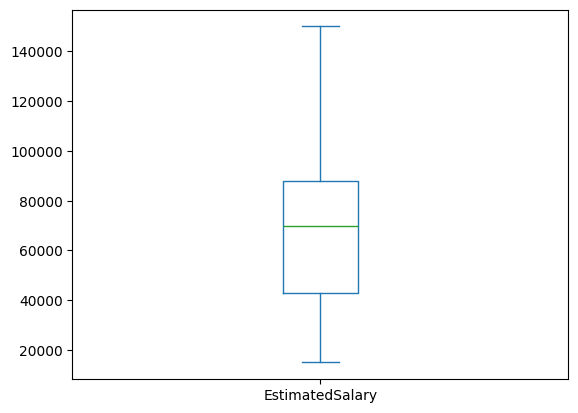

In [7]:
df['EstimatedSalary'].plot.box()

In [8]:
df.drop('Gender',axis=1,inplace=True)

In [9]:
df.drop('User ID',axis=1,inplace=True)

In [10]:
x = df.drop('Purchased',axis=1)  #drop column
y = df['Purchased']

In [11]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [12]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [13]:
x.shape

(400, 2)

In [14]:
y.shape

(400,)

In [15]:
#Feature Scaling

from sklearn.model_selection import train_test_split
x_train, x_test, Y_train, Y_test = train_test_split(x,y,test_size=0.25,random_state=0)

In [16]:
x_train.shape

(300, 2)

In [17]:
x_test.shape

(100, 2)

In [18]:
from sklearn.preprocessing import  StandardScaler

In [19]:
std = StandardScaler()

In [20]:
x_train = std.fit_transform(x_train)
x_test = std.fit_transform(x_test)

In [21]:
#Model Training
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_predict = model.predict(x_test)

In [23]:
y_predict

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [25]:
#Performance Evaluation
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [26]:
acc = accuracy_score(Y_test,y_predict)
acc

0.87

In [27]:
pre = precision_score(Y_test,y_predict)
pre

0.8275862068965517

In [28]:
rec= recall_score(Y_test,y_predict)
rec

0.75

In [29]:
#Classfication Report
from sklearn.metrics import classification_report
R = classification_report(Y_test,y_predict)
print(R)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        68
           1       0.83      0.75      0.79        32

    accuracy                           0.87       100
   macro avg       0.86      0.84      0.85       100
weighted avg       0.87      0.87      0.87       100



In [30]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [31]:
cm = confusion_matrix(Y_test,y_predict)

In [32]:
cm

array([[63,  5],
       [ 8, 24]])

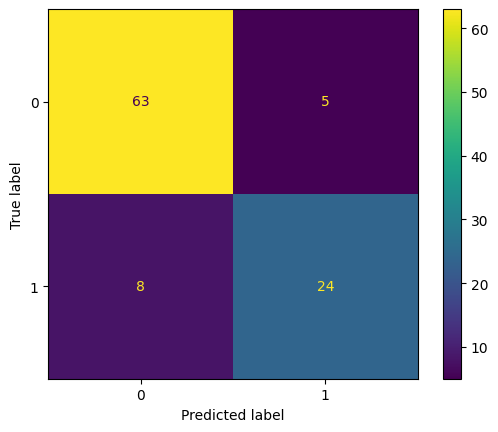

In [33]:
cm_d = ConfusionMatrixDisplay(cm).plot()

In [34]:
p_value = [(7,1000)]
new_predict  = model.predict(p_value)

In [35]:
new_predict

array([1])